In [1]:
# @title Load Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# @title Load student data in data frame
df = pd.read_csv('/content/student-mat.csv', sep=";")
df.describe(include="all")
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


Checking null values....
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
Checking invalid values....
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout 

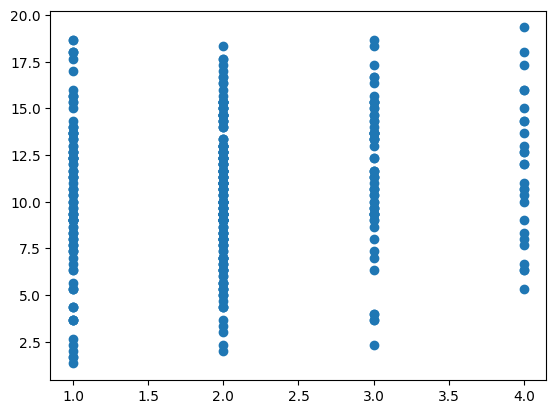

In [5]:
# @title Data Analysis
print("Checking null values....")
print(df.isnull().sum())
print("Checking invalid values....")
print(df.isna().sum())
# Create an array of studytime from df.studytime
arrStudytime = df.studytime.to_numpy()
#Calculate average of G1,G2,G3 for each row of df
arrAverageScore = (df.G1+df.G2+df.G3)/3

# Plot a scatter plot between arrStudyTime and arrAverageScore
plt.scatter(arrStudytime,arrAverageScore)
plt.show()


In [6]:
# @title Encode columns for regression

#Using LabelEncoder to encode School, sex, address, schoolsup, famsup,paid, nursery
df['school'] = LabelEncoder().fit_transform(df['school'])
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['address'] = LabelEncoder().fit_transform(df['address'])
df['schoolsup'] = LabelEncoder().fit_transform(df['schoolsup'])
df['famsup'] = LabelEncoder().fit_transform(df['famsup'])
df['paid'] = LabelEncoder().fit_transform(df['paid'])
df['nursery']= LabelEncoder().fit_transform(df['nursery'])
df


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,1,20,1,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,1,1,17,1,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,1,1,21,0,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,1,1,18,0,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [7]:
# @title Create another dataset for selected columns
# Creating DF for selected columns - 'school', 'sex', 'age', 'address', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'freetime', 'health', 'absences'
df_selected = df[['school', 'sex', 'age', 'address', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'nursery', 'freetime', 'health', 'absences','G1','G2','G3']]
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    int64
 1   sex         395 non-null    int64
 2   age         395 non-null    int64
 3   address     395 non-null    int64
 4   traveltime  395 non-null    int64
 5   studytime   395 non-null    int64
 6   failures    395 non-null    int64
 7   schoolsup   395 non-null    int64
 8   famsup      395 non-null    int64
 9   paid        395 non-null    int64
 10  nursery     395 non-null    int64
 11  freetime    395 non-null    int64
 12  health      395 non-null    int64
 13  absences    395 non-null    int64
 14  G1          395 non-null    int64
 15  G2          395 non-null    int64
 16  G3          395 non-null    int64
dtypes: int64(17)
memory usage: 52.6 KB


Text(0, 0.5, 'Frequency')

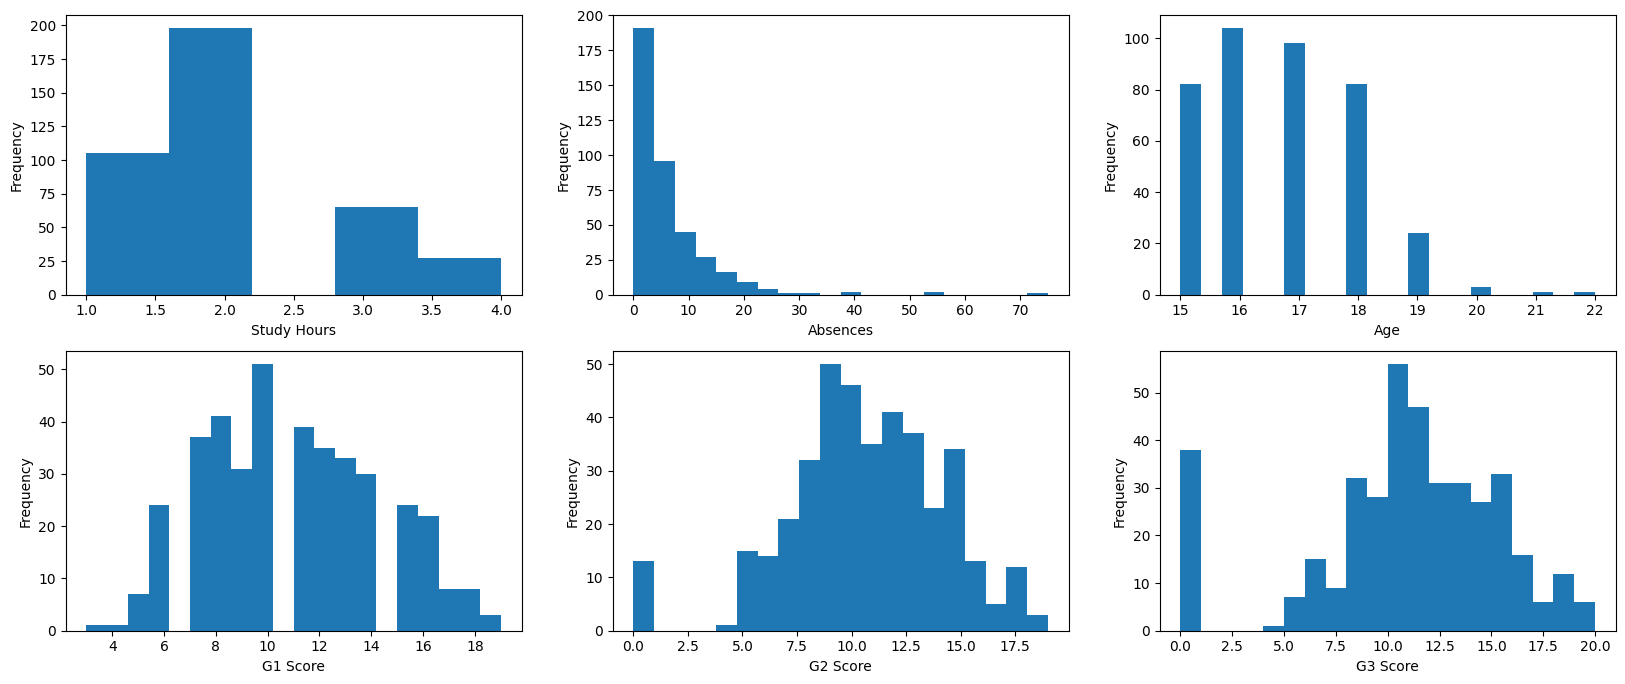

In [8]:
# @title Plot the distribution of study hours, scores, and attendance.
fig, axs = plt.subplots(2, 3, figsize=(20, 8))

#Create distribution for study hours
axs[0, 0].hist(df_selected['studytime'], bins=5)
axs[0, 0].set_xlabel('Study Hours')
axs[0, 0].set_ylabel('Frequency')

#Create distribution of attendance
axs[0, 1].hist(df_selected['absences'], bins=20)
axs[0, 1].set_xlabel('Absences')
axs[0, 1].set_ylabel('Frequency')

#Create distribution of Age
axs[0, 2].hist(df_selected['age'], bins=20)
axs[0, 2].set_xlabel('Age')
axs[0, 2].set_ylabel('Frequency')

#Create distribution of G1 score
axs[1, 0].hist(df_selected['G1'], bins=20)
axs[1, 0].set_xlabel('G1 Score')
axs[1, 0].set_ylabel('Frequency')

#Create distribution of G1 score
axs[1, 1].hist(df_selected['G2'], bins=20)
axs[1, 1].set_xlabel('G2 Score')
axs[1, 1].set_ylabel('Frequency')

#Create distribution of G3 score
axs[1, 2].hist(df_selected['G3'], bins=20)
axs[1, 2].set_xlabel('G3 Score')
axs[1, 2].set_ylabel('Frequency')

In [ ]:
# @title Analyze relationship and impact of data fields on G1,G2,G3 scores
#Create a correlation matrix and heatmap for Df_Selected
corr_matrix = df_selected.corr()
print(corr_matrix)

              school       sex       age   address  traveltime  studytime  \
school      1.000000 -0.012286  0.377610 -0.279797    0.242308  -0.090681   
sex        -0.012286  1.000000 -0.028606 -0.028504    0.059722  -0.306268   
age         0.377610 -0.028606  1.000000 -0.146722    0.070641  -0.004140   
address    -0.279797 -0.028504 -0.146722  1.000000   -0.328096  -0.020912   
traveltime  0.242308  0.059722  0.070641 -0.328096    1.000000  -0.100909   
studytime  -0.090681 -0.306268 -0.004140 -0.020912   -0.100909   1.000000   
failures    0.059804  0.044436  0.243665 -0.078578    0.092239  -0.173563   
schoolsup  -0.139789 -0.138271 -0.251811  0.024712   -0.009246   0.037763   
famsup     -0.164967 -0.151623 -0.140609  0.023903   -0.003286   0.145228   
paid       -0.017083 -0.129126 -0.035933  0.052800   -0.066420   0.167220   
nursery    -0.089277 -0.008203 -0.086632  0.059589   -0.033338   0.081325   
freetime    0.032988  0.238744  0.016434  0.034878   -0.017025  -0.143198   

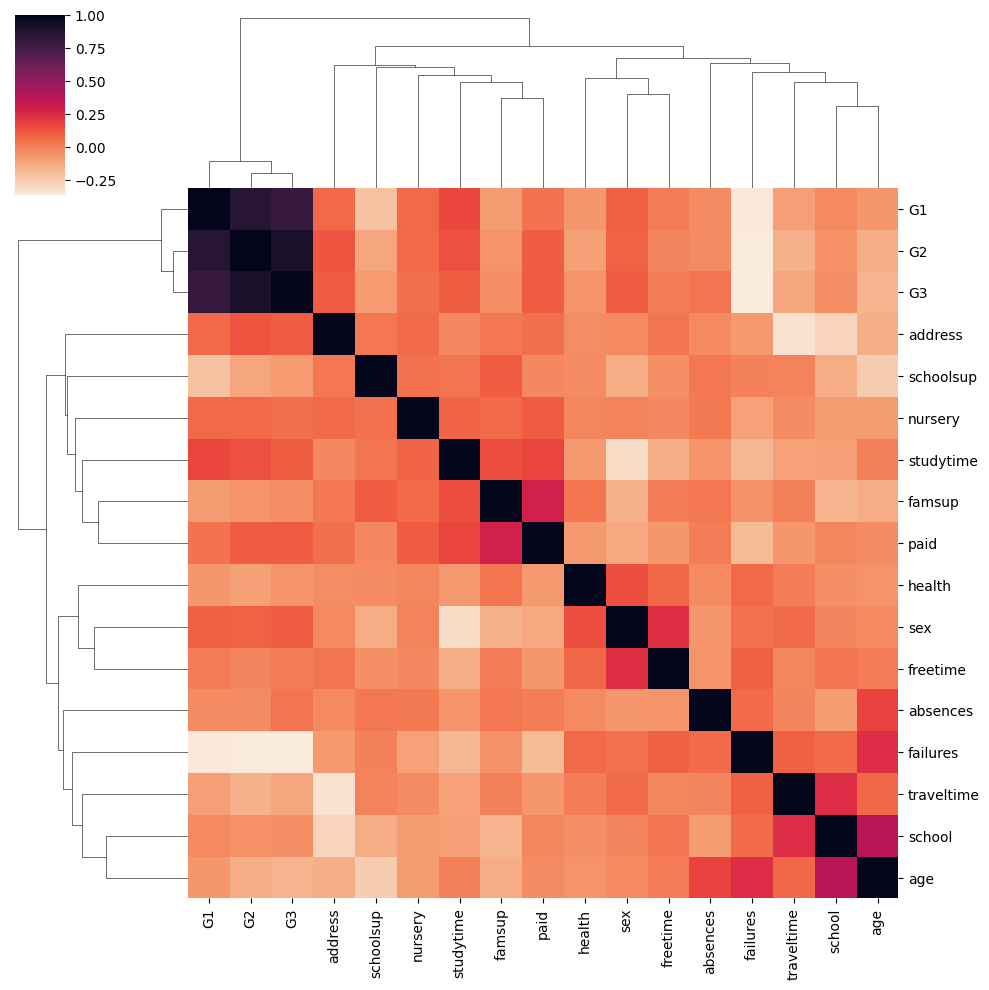

In [ ]:
sns_plot = sns.clustermap(corr_matrix, cmap="rocket_r")

In [ ]:
#Identifying columns with higher impact on score

selected_columns = ['G1', 'G2','G3']
# find all cols from corr matrix where there is a negative corr
print(corr_matrix[selected_columns][corr_matrix[selected_columns] < (-0.3)].dropna(how='all'))
# find all cols from corr matrix where there is a positive corr
print(corr_matrix[selected_columns][corr_matrix[selected_columns] > (0.0)].dropna(how='all'))

                G1        G2        G3
failures -0.354718 -0.355896 -0.360415
                 G1        G2        G3
sex        0.091839  0.091099  0.103456
address    0.069704  0.126037  0.105756
studytime  0.160612  0.135880  0.097820
paid       0.039079  0.105198  0.101996
nursery    0.069263  0.068146  0.051568
freetime   0.012613       NaN  0.011307
absences        NaN       NaN  0.034247
G1         1.000000  0.852118  0.801468
G2         0.852118  1.000000  0.904868
G3         0.801468  0.904868  1.000000


In [ ]:
# Create a dataframe for the following columns from DF - Failures, address, studytime, paid, nursery,sex, G1,g2,g3
# Columns selected based on correlation
# dropped columns - freetime, absences,
df_final = df[[ 'sex',  'address',  'studytime', 'failures',  'paid', 'nursery', 'G1','G2','G3']]
df_final.describe()


,sex,address,studytime,failures,paid,nursery,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.473418,0.777215,2.035443,0.334177,0.458228,0.794937,10.908861,10.713924,10.415190
std,0.499926,0.416643,0.839240,0.743651,0.498884,0.404260,3.319195,3.761505,4.581443
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,8.000000,9.000000,8.000000
50%,0.000000,1.000000,2.000000,0.000000,0.000000,1.000000,11.000000,11.000000,11.000000
75%,1.000000,1.000000,2.000000,0.000000,1.000000,1.000000,13.000000,13.000000,14.000000
max,1.000000,1.000000,4.000000,3.000000,1.000000,1.000000,19.000000,19.000000,20.000000


In [ ]:
# @title Identify outliers for G1, G2, G3


# Define a function to find outliers using Inter Quartile Range

def find_outliers_iqr(df_columnName:str):

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
  Q1 = df_final[df_columnName].quantile(0.25)
  Q3 = df_final[df_columnName].quantile(0.75)
  IQR = Q3 - Q1

# Identify outliers
  outliers = df_final[(df_final[df_columnName] < (Q1 - 1.5 * IQR)) | (df_final[df_columnName] > (Q3 + 1.5 * IQR))]

  print(df_columnName +" - Outliers using IQR:")
  print(outliers)

#End finction

find_outliers_iqr('G1')
find_outliers_iqr('G2')
find_outliers_iqr('G3')



G1 - Outliers using IQR:
Empty DataFrame
Columns: [sex, address, studytime, failures, paid, nursery, G1, G2, G3]
Index: []
G2 - Outliers using IQR:
     sex  address  studytime  failures  paid  nursery  G1  G2  G3
130    0        0          3         2     0        1  12   0   0
131    0        1          1         0     0        0   8   0   0
134    1        0          2         0     0        1   9   0   0
135    0        1          3         0     0        1  11   0   0
136    1        0          2         0     0        1  10   0   0
137    0        1          1         2     0        0   4   0   0
144    1        1          1         3     0        1   5   0   0
153    1        1          1         3     0        1   5   0   0
162    1        1          1         1     0        1   7   0   0
242    1        1          1         0     0        0   6   0   0
244    0        1          3         0     1        0   7   0   0
269    0        0          2         0     0        1   6   

In [ ]:
# @title Build a regression model from df_final to predict values for G3
# create a linear regression model from df_final to predict values for G3

model_test_Size = 0.80

params = ['G1', 'G2', 'sex', 'address', 'studytime', 'failures', 'paid', 'nursery']
paramsX = df_final[params]
paramsY = df_final['G3']

# Divide data into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(paramsX, paramsY, test_size=model_test_Size, random_state=42)

# Fit the regression model using X_Train and Y_Train

model = LinearRegression()
model.fit(X_train, y_train)

# Predict G3 values for X_Test
y_pred = model.predict(X_test)


In [ ]:
# @title Regression Model Accuracy
#Check accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

# Calculate MAE, MSE, RMSE, and R² score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Accuracy: 0.8210745543697235
Mean Absolute Error (MAE): 1.216669983671557
Mean Squared Error (MSE): 3.8770070713206444
Root Mean Squared Error (RMSE): 1.9690116991324973
R-squared (R²): 0.8210745543697235


In [ ]:
# @title Reducing predective parameters to identify the impact on model

params = ['G1', 'G2', 'address', 'studytime', 'failures', 'paid', 'nursery']
paramsX = df_final[params]
paramsY = df_final['G3']

# Divide data into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(paramsX, paramsY, test_size=model_test_Size, random_state=42)

# Fit the regression model using X_Train and Y_Train

model = LinearRegression()
model.fit(X_train, y_train)

# Predict G3 values for X_Test
y_pred = model.predict(X_test)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)




Accuracy: 0.8207191692184266


In [ ]:
#Recalculate Accuracy

# Calculate MAE, MSE, RMSE, and R² score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 1.2166675037941768
Mean Squared Error (MSE): 3.88470765711361
Root Mean Squared Error (RMSE): 1.9709661735082138
R-squared (R²): 0.8207191692184266


In [ ]:
# @title Multiple regression with the 'studytime', 'failures', 'paid' parameter

params = ['G1', 'G2',  'studytime', 'failures', 'paid']
paramsX = df_final[params]
paramsY = df_final['G3']

# Divide data into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(paramsX, paramsY, test_size=model_test_Size, random_state=42)

#Using Scalar transform to scale the traing and test data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fit the regression model using X_Train and Y_Train

model = LinearRegression()
model.fit(X_train, y_train)

# Predict G3 values for X_Test
y_pred = model.predict(X_test)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)


#Calculate MAE, MSE, RMSE, and R² score.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAE, MSE, RMSE, and R² score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Accuracy: 0.8234780496192244
Mean Absolute Error (MAE): 1.200897290547856
Mean Squared Error (MSE): 3.8249274576839367
Root Mean Squared Error (RMSE): 1.9557421756673186
R-squared (R²): 0.8234780496192244


In [ ]:
# Add a new column to df_final for Pass and Fail so as if total score (G1+G2+G3) >40 then its "Pass" else fail
df_final['Result'] = np.where((df_final['G1']+df_final['G2']+df_final['G3']) > 40, 'Pass', 'Fail')
df_final

<ipython-input-17-9f3eeb7fde5c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Result'] = np.where((df_final['G1']+df_final['G2']+df_final['G3']) > 40, 'Pass', 'Fail')


,sex,address,studytime,failures,paid,nursery,G1,G2,G3,Result
0,0,1,2,0,0,1,5,6,6,Fail
1,0,1,2,0,0,0,5,5,6,Fail
2,0,1,2,3,1,1,7,8,10,Fail
3,0,1,3,0,1,1,15,14,15,Pass
4,0,1,2,0,1,1,6,10,10,Fail
...,...,...,...,...,...,...,...,...,...,...
390,1,1,2,2,1,1,9,9,9,Fail
391,1,1,1,0,0,0,14,16,16,Pass
392,1,0,1,3,0,0,10,8,7,Fail
393,1,0,1,0,0,0,11,12,10,Fail


In [ ]:
# @title Using Logistic Regression to classify students as Pass or Fail
# Using logistic alogorithm for binary classification, creating a model to classify the result column

#Using LabelEncoder for 'Result' column
df_final['Result'] = LabelEncoder().fit_transform(df_final['Result'])

#Selecting  predictive parameters
trainParams = ['studytime', 'failures', 'paid','G1', 'G2', 'G3']
trainParamsX = df_final[trainParams]
trainParamsY = df_final['Result']

# Creating 80% training and 20% test data
X_train, X_test, y_train, y_test = train_test_split(trainParamsX, trainParamsY, test_size=model_test_Size, random_state=42)

# Using Standard scaler for trainign data of df_final
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<ipython-input-18-714a404e1f8a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Result'] = LabelEncoder().fit_transform(df_final['Result'])


In [ ]:
#logistic regression model using X_Train and Y_Train
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Using the Y Test to generate prediction for result column
y_pred = model.predict(X_test)

In [ ]:
# Using Mean Absolute Error, Squared Error, R2 values for accuracy

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 0.03481012658227848
Mean Squared Error (MSE): 0.03481012658227848
Root Mean Squared Error (RMSE): 0.18657472117700855
R-squared (R²): 0.8094298245614036


[[236   4]
 [  7  69]]


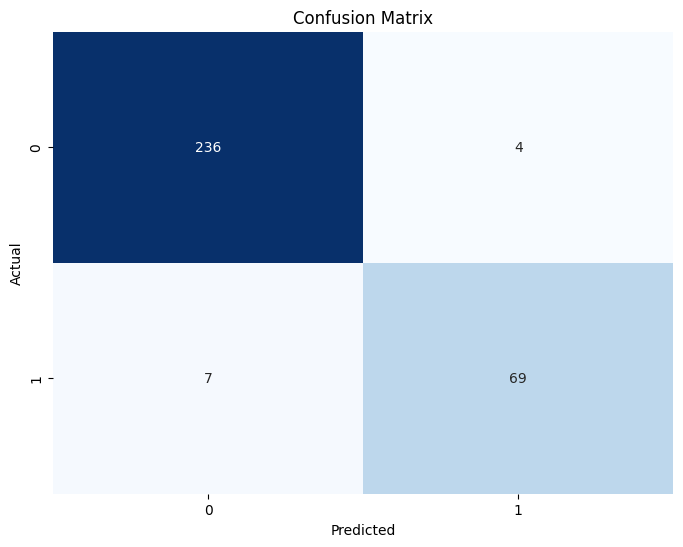

Accuracy: 0.9651898734177216
Precision: 0.9452054794520548
Recall: 0.9078947368421053
F1 Score: 0.9261744966442953


In [ ]:
# Creating a confusion matrix for the predictions
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#Calculate Accuracy, Precision, Recall, and F1 Score.
accuracy = accuracy_score(y_test, y_pred)
precision = cm[1, 1] / (cm[0, 1] + cm[1, 1])
recall = cm[1, 1] / (cm[1, 0] + cm[1, 1])
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)